In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy
import numpy as np
from numpy import cov
from numpy import trace
from numpy import iscomplexobj
from numpy import asarray
from numpy.random import randint
from scipy.linalg import sqrtm
from keras.applications.inception_v3 import InceptionV3
from keras.applications.inception_v3 import preprocess_input
from keras.datasets.mnist import load_data
from skimage.transform import resize

latent_dim = 128
batch_size = 64

In [6]:
# calculate frechet inception distance
def fid_score(batch1, batch2):
    batch1, batch2 = batch1.numpy(), batch2.numpy()
    # scale an array of images to a new size
    def scale_images(images, new_shape):
        images_list = list()
        for image in images:
            # resize with nearest neighbor interpolation
            new_image = resize(image, new_shape, 0)
            # store
            images_list.append(new_image)
        return asarray(images_list)
    # prepare the inception v3 model
    model = InceptionV3(include_top=False, pooling='avg', input_shape=(299,299,3))
    # resize images
    batch1 = scale_images(batch1, (299,299,3))
    batch2 = scale_images(batch2, (299,299,3))
    # pre-process images
    batch1 = preprocess_input(batch1)
    batch2 = preprocess_input(batch2)
    # calculate feature embeddings
    embedding1 = model.predict(batch1)
    embedding2 = model.predict(batch2)
    # calculate mean and covariance statistics
    mu1, sigma1 = embedding1.mean(axis=0), cov(embedding1, rowvar=False)
    mu2, sigma2 = embedding2.mean(axis=0), cov(embedding2, rowvar=False)
    # calculate sum squared difference between means
    ssdiff = numpy.sum((mu1 - mu2)**2.0)
    # calculate sqrt of product between cov
    covmean = sqrtm(sigma1.dot(sigma2))
    # check and correct imaginary numbers from sqrt
    if iscomplexobj(covmean):
        covmean = covmean.real
    # calculate fid score
    fid = ssdiff + trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

In [7]:
discriminator = keras.Sequential(
    [
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, (3, 3), strides=(2, 2), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(128, (3, 3), strides=(2, 2), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.GlobalMaxPooling2D(),
        layers.Dense(1),
    ],
    name="discriminator",
)

generator = keras.Sequential(
    [
        keras.Input(shape=(latent_dim,)),
        # We want to generate 128 coefficients to reshape into a 7x7x128 map
        layers.Dense(7 * 7 * 128),
        layers.LeakyReLU(alpha=0.2),
        layers.Reshape((7, 7, 128)),
        layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"),
        layers.LeakyReLU(alpha=0.2),
        layers.Conv2D(1, (7, 7), padding="same", activation="sigmoid"),
    ],
    name="generator",
)

# Instantiate one optimizer for the discriminator and another for the generator.
d_optimizer = keras.optimizers.Adam(learning_rate=0.0003)
g_optimizer = keras.optimizers.Adam(learning_rate=0.0004)

# Instantiate a loss function.
loss_fn = keras.losses.BinaryCrossentropy(from_logits=True)

@tf.function
def train_step(real_images):
    # Sample random points in the latent space
    random_latent_vectors = tf.random.normal(shape=(batch_size, latent_dim))
    # Decode them to fake images
    generated_images = generator(random_latent_vectors)
    # Combine them with real images
    combined_images = tf.concat([generated_images, real_images], axis=0)

    # Assemble labels discriminating real from fake images
    labels = tf.concat(
        [tf.ones((batch_size, 1)), tf.zeros((real_images.shape[0], 1))], axis=0
    )
    # Add random noise to the labels - important trick!
    labels += 0.05 * tf.random.uniform(labels.shape)

    # Train the discriminator
    with tf.GradientTape() as tape:
        predictions = discriminator(combined_images)
        d_loss = loss_fn(labels, predictions)
    grads = tape.gradient(d_loss, discriminator.trainable_weights)
    d_optimizer.apply_gradients(zip(grads, discriminator.trainable_weights))

    # Sample random points in the latent space
    random_latent_vectors = tf.random.normal(shape=(batch_size, latent_dim))
    # Assemble labels that say "all real images"
    misleading_labels = tf.zeros((batch_size, 1))

    # Train the generator (note that we should *not* update the weights
    # of the discriminator)!
    with tf.GradientTape() as tape:
        predictions = discriminator(generator(random_latent_vectors))
        g_loss = loss_fn(misleading_labels, predictions)
    grads = tape.gradient(g_loss, generator.trainable_weights)
    g_optimizer.apply_gradients(zip(grads, generator.trainable_weights))
    return d_loss, g_loss, generated_images

In [11]:
# Prepare the dataset. We use both the training & test MNIST digits.
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
all_digits = np.concatenate([x_train, x_test])
all_digits = all_digits.astype("float32") / 255.0
all_digits = np.reshape(all_digits, (-1, 28, 28, 1))
dataset = tf.data.Dataset.from_tensor_slices(all_digits)
dataset = dataset.shuffle(buffer_size=1024).batch(batch_size)
generator_losses, discriminator_losses, fid_scores = [], [], []

epochs = 20
for epoch in range(epochs):
    for step, real_batch in enumerate(dataset):
        # Train the discriminator & generator on one batch of real images.
        d_loss, g_loss, generated_batch = train_step(real_batch)
            
    
    fid = fid_score(generated_batch, real_batch)
    fid_scores.append(fid)
    generator_losses.append(g_loss)
    discriminator_losses.append(d_loss)
    # Print metrics
    print("epoch: %d, d_loss: %.2f, g_loss: %.2f, fid: %.2f" % (epoch+1, d_loss, g_loss, fid))

epoch: 1, d_loss: 0.66, g_loss: 1.00, fid: 4.35
epoch: 2, d_loss: 0.65, g_loss: 0.99, fid: 4.33
epoch: 3, d_loss: 0.61, g_loss: 0.99, fid: 4.47
epoch: 4, d_loss: 0.59, g_loss: 1.02, fid: 4.48
epoch: 5, d_loss: 0.63, g_loss: 1.02, fid: 4.22
epoch: 6, d_loss: 0.62, g_loss: 1.06, fid: 4.73
epoch: 7, d_loss: 0.62, g_loss: 0.95, fid: 4.87
epoch: 8, d_loss: 0.58, g_loss: 1.24, fid: 4.87
epoch: 9, d_loss: 0.60, g_loss: 1.12, fid: 4.51
epoch: 10, d_loss: 0.60, g_loss: 1.18, fid: 4.72
epoch: 11, d_loss: 0.62, g_loss: 0.99, fid: 4.13
epoch: 12, d_loss: 0.56, g_loss: 1.00, fid: 4.34
epoch: 13, d_loss: 0.60, g_loss: 1.10, fid: 4.22
epoch: 14, d_loss: 0.61, g_loss: 1.13, fid: 4.04
epoch: 15, d_loss: 0.59, g_loss: 1.09, fid: 3.86
epoch: 16, d_loss: 0.63, g_loss: 1.18, fid: 3.36
epoch: 17, d_loss: 0.67, g_loss: 1.16, fid: 3.73
epoch: 18, d_loss: 0.65, g_loss: 1.09, fid: 4.11
epoch: 19, d_loss: 0.59, g_loss: 1.11, fid: 4.52
epoch: 20, d_loss: 0.62, g_loss: 1.14, fid: 3.89


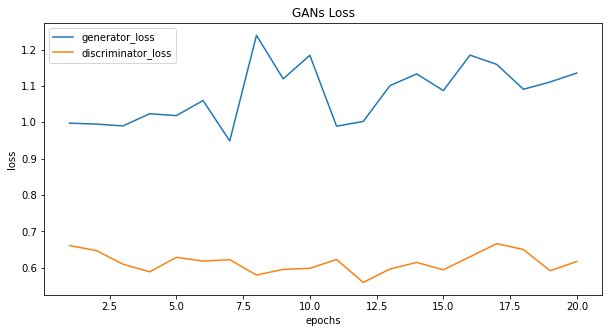

In [23]:
plt.figure(figsize = (10,5))
plt.plot(np.arange(len(generator_losses))+1,generator_losses, label = 'generator_loss')
plt.plot(np.arange(len(discriminator_losses))+1,discriminator_losses, label = 'discriminator_loss')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("GANs Loss")
plt.legend()
plt.show()

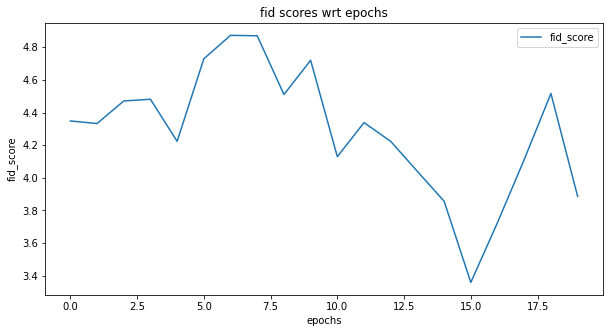

In [24]:
plt.figure(figsize = (10,5))
plt.plot(fid_scores, label = "fid_score")
plt.xlabel("epochs")
plt.ylabel("fid_score")
plt.legend()
plt.title("fid scores wrt epochs")
plt.show()

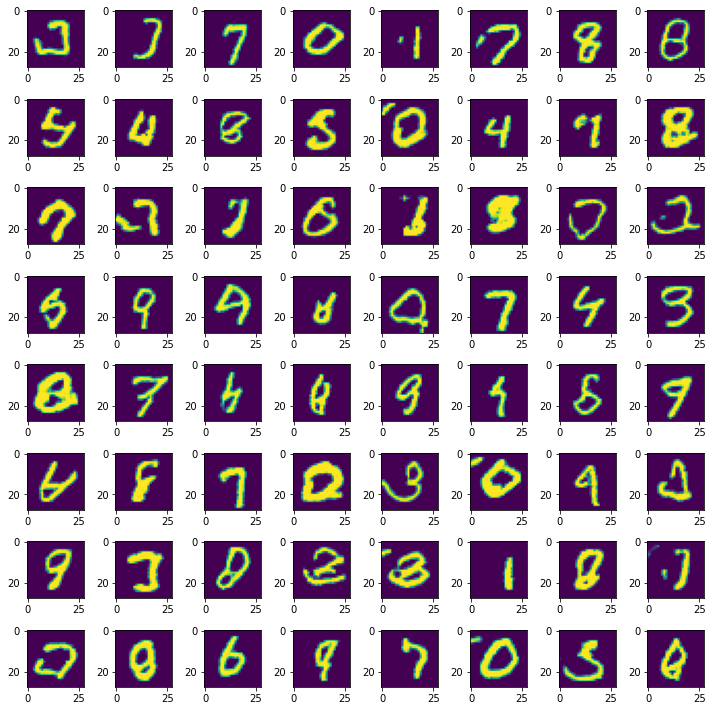

In [17]:
random_latent_vectors = tf.random.normal(shape=(batch_size, latent_dim))
# Decode them to fake images
generated_images = generator(random_latent_vectors)

import matplotlib.pyplot as plt
plt.figure(figsize = (10,10))
for i in range(64):
    plt.subplot(8, 8, i+1)
    plt.imshow(generated_images[i])
    plt.tight_layout()
plt.show()